In [224]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation='varimax')

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

/Users/ronan/Developer/reeval-multi/mirt-official/load_params.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(model_path, map_location=torch.dev

--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 19])
Original 'a' matrix shape: torch.Size([78712, 19])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 19)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 19)

--- Final Standardized Z-Scores (from transformed theta) ---
These are the scores you should use for interpretation.
[[ 1.36679121 -1.29142072  0.02368664 ...  0.5948743   1.20452549
  -1.32143699]
 [ 0.8694796   0.65897874 -2.01923406 ... -0.49557078  1.18055759
  -1.37415132]
 [ 1.82481648 -1.4122685  -0.51204663 ...  0.78741921 -0.97111116
  -1.49879246]
 ...
 [-0.9912067  -0.93205986 -0.40201418 ...  0.99411487 -0.17602767
   1.24166521]
 [-0.71577314 -0.59205097 -0.52410342 ...  1.13348854 -0.10466067
   0.66230223]
 [ 0.18720646 -0.9709694   0.55470963 ...  0.3900838   1.68143397
  -0.28299898]]


## PCA analysis

In [225]:
import numpy as np
import pandas as pd

def compute_scalar_ability(theta_df, a_df, b_series, item_ids, v_unit=None, adjust_difficulty=True):
	"""
	Compute a math-specific ability score from MIRT factors, discriminations, and difficulties.
	
	Args:
		theta_df (pd.DataFrame): Factor scores per test taker (rows = test takers, cols = factors).
		a_df (pd.DataFrame): Discrimination parameters (rows = items, cols = factors).
		b_series (pd.Series): Difficulty parameters (indexed same as a_df rows).
		item_ids (list): List of item IDs (subset of a_df rows) that are math items.
		adjust_difficulty (bool): Whether to weight discriminations by difficulty.
	
	Returns:
		pd.Series: Math ability scores for each test taker.
	"""
	if v_unit is None:
		# 1. Extract discrimination vectors for math items
		A_math = a_df.loc[item_ids].copy()
		b_math = b_series.loc[item_ids]

		# 2. Optionally adjust by difficulty
		if adjust_difficulty:
			weights = 1 / (1 + np.abs(b_math.values))
			A_math = A_math.multiply(weights, axis=0)

		# 3. Compute math direction vector in factor space
		v_unit = A_math.mean(axis=0).values  # vector of length = num_factors
		v_unit = v_unit / np.linalg.norm(v_unit)  # normalize for stability
		print("Mean unit vector: ", v_unit)

	else: 
		print("Used pre-computed math direction vector.", v_unit)

	# 4. Project each test taker's theta onto v_unit
	theta_matrix = theta_df.values  # shape (n_test_takers, n_factors)
	math_scores = theta_matrix.dot(v_unit)

	return pd.Series(math_scores, index=theta_df.index, name="ability")


In [226]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)


def compute_pca(theta_df, a_df, item_ids, adjust_difficulty=True,
                     return_mean_vector=False, variance_threshold=0.8, b_series=None, save_path='../result/PCA_explained.pdf',
                     num_pcs=None):
    """
    Compute math-specific ability dimensions using PCA on discrimination vectors,
    and plot explained variance with threshold.
    
    Args:
        theta_df (pd.DataFrame): Factor scores (models/test-takers x factors)
        a_df (pd.DataFrame): Discrimination parameters (items x factors)
        item_ids (list): List of item IDs considered
        adjust_difficulty (bool): Weight items by difficulty if desired
        return_mean_vector (bool): Also compute the mean-based math vector for comparison
        variance_threshold (float): Cumulative explained variance threshold for selecting PCs
        b_series (pd.Series, optional): Item difficulty for weighting
        
    Returns:
        dict:
            'pca_vectors': numpy array (unit vectors of PCs)
            'pca_loadings': pandas DataFrame of factor loadings per PC
            'mean_vector': numpy array (unit vector of mean, optional)
            'scalar_scores': pd.DataFrame of projected scores for each PC
            'explained_variance': array of variance explained per PC
            'num_pcs_above_threshold': int, number of PCs needed to reach cumulative threshold
    """
    # 1. Extract item discriminations
    A_math = a_df.loc[item_ids].copy()

    print(A_math.shape)
    
    # 2. Optional: adjust by difficulty
    if adjust_difficulty and b_series is not None:
        b_math = b_series.loc[item_ids]
        weights = 1 / (1 + np.abs(b_math.values))
        A_math = A_math.multiply(weights, axis=0)

    # 3. Fit PCA on all math items
    if num_pcs is None:
        pca = PCA()
        pca.fit(A_math.values)
    else:
        pca = PCA(n_components=num_pcs)
        pca.fit(A_math.values)
        
    pca_vectors = pca.components_  # shape: n_pcs x n_factors
    # Normalize each PC to unit vector
    pca_vectors = np.array([v / np.linalg.norm(v) for v in pca_vectors])
    
    # 4. Compute factor loadings per PC
    # Loading of PC on original factor = eigenvector * sqrt(eigenvalue)
    pca_loadings = pd.DataFrame(
        pca_vectors.T * np.sqrt(pca.explained_variance_),
        index=A_math.columns,
        columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])]
    )
    
    item_loadings = pd.DataFrame(
		A_math.values.dot(pca_vectors.T),
		index=A_math.index,
		columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])]
	)

    print(A_math.values.dot(pca_vectors.T).shape)
    print(pca_vectors.T.shape)
    
    # 5. Optional: compute mean vector for comparison
    v_mean = None
    if return_mean_vector:
        v_mean = A_math.mean(axis=0).values
        v_mean /= np.linalg.norm(v_mean)
    
    # 6. Project theta onto all PCs
    scalar_scores = pd.DataFrame(theta_df.values.dot(pca_vectors.T),
                                 index=theta_df.index,
                                 columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])])
    
    # 7. Compute cumulative variance and threshold
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    num_pcs_above_threshold = np.searchsorted(cumulative_variance, variance_threshold) + 1
    # 8. Plot explained variance and cumulative variance
    plt.figure(figsize=(6,4))
    plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.6, label='Individual PC')
    plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, color='firebrick', marker='o', label='Cumulative')
    plt.axhline(y=variance_threshold, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.xticks(range(1, len(explained_variance)+1, 2))
    plt.xlabel('PC')
    plt.ylabel('Variance')
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    
    return {
        'pca_vectors': pca_vectors,
        'pca_loadings': pca_loadings,
        'item_loadings': item_loadings,
        'mean_vector': v_mean,
        'scalar_scores': scalar_scores,
        'explained_variance': explained_variance,
        'num_pcs_above_threshold': num_pcs_above_threshold
    }

(1435, 19)
(1435, 19)
(19, 19)


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_45962/4093419182.py:104: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


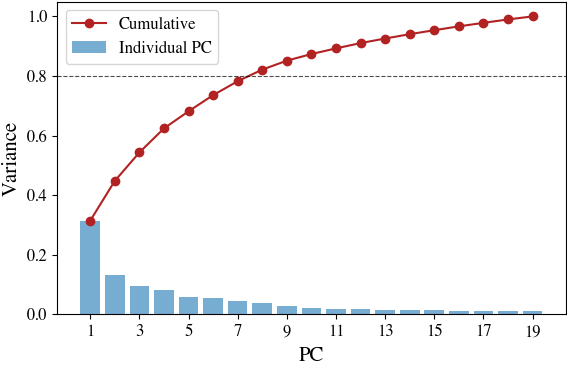

8


In [227]:
conv_dataset = ['math', 'gsm']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

pd.DataFrame(scenario_questions, columns=['question']).to_pickle('../result/math_scenario_questions.pkl')

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

result = compute_pca(theta_df, a_df, scenario_questions, return_mean_vector=True, save_path='../result/PCA_explained_med_qa.pdf')
scalar_scores = result['scalar_scores']
v_pca = result['pca_vectors']
variance = result['explained_variance']
num_pcs = result['num_pcs_above_threshold']
pca_loadings = result['pca_loadings']
item_loadings = result['item_loadings']
print(num_pcs)

In [228]:
commonsense_scores = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions)
commonsense_scores_pca = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_pca[2])

conv_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)
pca_convergent_corr = commonsense_scores_pca.corr(conv_benchmark_scores, method='spearman')
mean_convergent_corr = commonsense_scores.corr(conv_benchmark_scores, method='spearman')
print('pca_convergent_corr', pca_convergent_corr)
print('mean_convergent_corr', mean_convergent_corr)

div_benchmark_scores = resmat[resmat.columns[~resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)
mean_divergent_corr = commonsense_scores.corr(div_benchmark_scores, method='spearman')
print('mean_divergent_corr', mean_divergent_corr)

Mean unit vector:  [-6.34968495e-01 -1.02119559e-01  3.60821711e-04 -4.15805596e-02
 -2.39549046e-02 -1.85279114e-01  5.86017506e-02  8.66741521e-03
 -6.64989977e-01  1.41890720e-02  8.70454109e-02 -2.72272291e-02
  2.88952622e-01 -5.76374019e-02 -3.88385108e-02 -2.52336133e-02
 -7.88057589e-02  1.00002964e-02  1.56084981e-02]
Used pre-computed math direction vector. [-0.04109179  0.06398246  0.02457128 -0.01075866 -0.00540661 -0.2554918
  0.02167368  0.00751035 -0.68989299  0.00625338  0.03689763  0.01812463
 -0.26012047  0.01694773 -0.05986166 -0.02666722 -0.61378879  0.02163807
  0.02315283]
pca_convergent_corr 0.5814530353938689
mean_convergent_corr 0.9585319143689968
mean_divergent_corr 0.5874656348640669


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_45962/3955957431.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


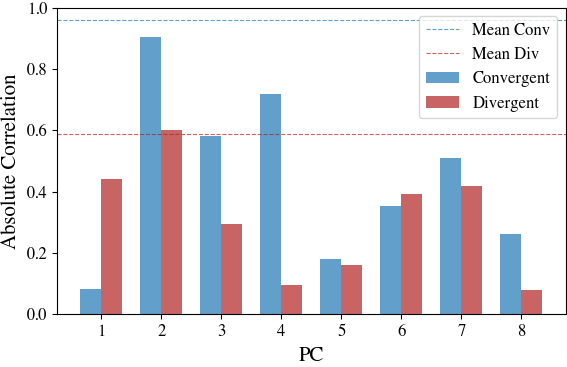

In [229]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlations for PC1, PC2, PC3
pcs = [f'PC{i+1}' for i in range(num_pcs)]
conv_corrs = []
div_corrs = []

for pc in pcs:
    conv_corr = abs(scalar_scores[pc].corr(conv_benchmark_scores, method='spearman'))
    div_corr = abs(scalar_scores[pc].corr(div_benchmark_scores, method='spearman'))
    conv_corrs.append(conv_corr)
    div_corrs.append(div_corr)

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)


# Add horizontal dashed lines
ax.axhline(y=abs(mean_convergent_corr), color='C0', linestyle='--', alpha=0.7, label='Mean Conv', linewidth=0.8)
ax.axhline(y=abs(mean_divergent_corr), color='firebrick', linestyle='--', alpha=0.7, label='Mean Div', linewidth=0.8)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('PC')
ax.set_xticks(x)
ax.set_xticklabels([f'{i+1}' for i in range(num_pcs)])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(f'../result/pc_correlations_histogram_{"".join(conv_dataset)}.pdf')
plt.show()

In [230]:
import pandas as pd
import numpy as np

def get_reference_composite_eigenvector(a_df: pd.DataFrame) -> np.ndarray:
    """
    Calculates the eigenvector for the reference composite from a matrix of 
    multidimensional discrimination parameters.

    This vector corresponds to the largest eigenvalue of the a'a matrix and 
    represents the direction of the dominant unidimensional scale in the 
    multidimensional space.

    Args:
        a_df: A pandas DataFrame with shape (n_items, n_dimensions) 
              containing the 'a' parameters.

    Returns:
        A NumPy array representing the eigenvector of the reference composite.
    """
    # Convert the DataFrame to a NumPy array for matrix operations
    a_matrix = a_df.to_numpy()
    
    # Calculate the a-transpose-a matrix (a'a)
    a_t_a = a_matrix.T @ a_matrix
    
    # Calculate the eigenvalues and eigenvectors of the a'a matrix
    eigenvalues, eigenvectors = np.linalg.eig(a_t_a)
    
    # Find the index of the largest eigenvalue
    max_eigenvalue_index = np.argmax(eigenvalues)
    
    # Select the corresponding eigenvector
    reference_composite_vector = eigenvectors[:, max_eigenvalue_index]
    
    return reference_composite_vector

In [231]:
defined_PCs = {
  "Multi-Step Quantitative Reasoning": 1,
  "Application of Formal Mathematical Concepts": 2,
  "Direct Translation to Computation": 3,
  "Procedural and Abstract Algebra": 4,
  "Algebraic Word Problem Formulation": 5,
  "Sequential Calculation with State-Tracking": 6,
  "Application of Ratios, Rates, and Proportions": 7,
  "Complex Integrated Problem Solving": 8,
}

sub_abilities = {
  "Chained Reasoning": [1, 8],
  "State Tracking": [6],
  "Ratios, Rates, and Proportions": [7],
  "Calculation": [4],
  "Fundamental Principles": [2],
  "Word Problem": [3],
  "Algebric Formulation": [5],
}

In [232]:
df_result = pd.read_pickle('../result/content_validation_res.pkl')
df_result = df_result[~df_result['skill'].str.contains("ERROR:")]
df_result['PC'] = df_result['skill'].map(defined_PCs)
df_result['sub_ability'] = df_result['PC'].apply(lambda x: ''.join([k for k, v in sub_abilities.items() if x in v]) if x else None)
print(df_result['PC'].value_counts())
df_result.drop(columns=['skill', 'rationale', 'PC'], inplace=True)

PC
3    881
2    158
6    110
1     84
7     69
5     68
4     57
8      4
Name: count, dtype: int64


In [233]:
  # "Chained Reasoning": [1, 8],
  # "State Tracking": [6],
  # "Ratios, Rates, and Proportions": [7],
  # "Calculation": [4],
  # "Fundamental Principles": [2],
  # "Word Problem": [3],
  # "Algebric Formulation": [5],
extracted_questions_1 = df_result[df_result['sub_ability'] == 'Chained Reasoning']['question'].to_list()
extracted_questions_2 = df_result[df_result['sub_ability'] == 'State Tracking']['question'].to_list()
extracted_questions_3 = df_result[df_result['sub_ability'] == 'Ratios, Rates, and Proportions']['question'].to_list()
extracted_questions_4 = df_result[df_result['sub_ability'] == 'Calculation']['question'].to_list()
extracted_questions_5 = df_result[df_result['sub_ability'] == 'Fundamental Principles']['question'].to_list()
extracted_questions_6 = df_result[df_result['sub_ability'] == 'Word Problem']['question'].to_list()
extracted_questions_7 = df_result[df_result['sub_ability'] == 'Algebric Formulation']['question'].to_list()

print(extracted_questions_1)
print(extracted_questions_2)
print(extracted_questions_3)
print(extracted_questions_4)
print(extracted_questions_5)
print(extracted_questions_6)
print(extracted_questions_7)


a_1 = a_df.loc[extracted_questions_1]
a_2 = a_df.loc[extracted_questions_2]
a_3 = a_df.loc[extracted_questions_3]
a_4 = a_df.loc[extracted_questions_4]
a_5 = a_df.loc[extracted_questions_5]
a_6 = a_df.loc[extracted_questions_6]
a_7 = a_df.loc[extracted_questions_7]

v_1 = get_reference_composite_eigenvector(a_1)
v_2 = get_reference_composite_eigenvector(a_2)
v_3 = get_reference_composite_eigenvector(a_3)
v_4 = get_reference_composite_eigenvector(a_4)
v_5 = get_reference_composite_eigenvector(a_5)
v_6 = get_reference_composite_eigenvector(a_6)
v_7 = get_reference_composite_eigenvector(a_7)

['Fourteen white cubes are put together to form the figure on the right.  The complete surface of the figure, including the bottom, is painted red.  The figure is then separated into individual cubes.  How many of the individual cubes have exactly four red faces?\n\n[asy]\nsize(150);\npair a=(1,0),b=(0,1),c=(0.45,0.4);\n\nvoid drawcube(pair loc){\n     filldraw(loc+b--loc--loc+a--loc+a+c--loc+a+b+c--loc+b+c--cycle,white);\n     draw(loc+b--loc+a+b--loc+a+b+c^^loc+a+b--loc+a);\n}\n\npair location[]={origin,b,a,2a,3a,3a+b,-c,3a-c,-2c,-2c+b,-2c+a,-2c+2a,-2c+3a,-2c+3a+b};\n\nfor(int i; i<14;++i){\n   drawcube(location[i]);\n}\n\n\n[/asy]', '44 seniors need to receive awards.  Each senior receives a picture frame that costs $20.  Each picture frame needs to be etched with the logo for an additional 20% cost per frame.  2 of the seniors will also receive pins that are $5.  1/4 of the seniors are officers and they will need to receive cords that are $12 each.  How much will be spent on the se

In [234]:
score_1 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_1)
score_2 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_2)
score_3 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_3)
score_4 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_4)
score_5 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_5)
score_6 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_6)
score_7 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_7)

conv_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)
pca_convergent_corr = commonsense_scores_pca.corr(conv_benchmark_scores, method='spearman')
mean_convergent_corr = commonsense_scores.corr(conv_benchmark_scores, method='spearman')

conv_score_1 = score_1.corr(conv_benchmark_scores, method='spearman')
conv_score_2 = score_2.corr(conv_benchmark_scores, method='spearman')
conv_score_3 = score_3.corr(conv_benchmark_scores, method='spearman')
conv_score_4 = score_4.corr(conv_benchmark_scores, method='spearman')
conv_score_5 = score_5.corr(conv_benchmark_scores, method='spearman')
conv_score_6 = score_6.corr(conv_benchmark_scores, method='spearman')
conv_score_7 = score_7.corr(conv_benchmark_scores, method='spearman')

print('conv score 1', conv_score_1)
print('conv score 2', conv_score_2)
print('conv score 4', conv_score_4)
print('conv score 5', conv_score_5)
print('conv score 6', conv_score_6)
print('conv score 7', conv_score_7)

div_benchmark_scores = resmat[resmat.columns[~resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_score_1 = score_1.corr(div_benchmark_scores, method='spearman')
div_score_2 = score_2.corr(div_benchmark_scores, method='spearman')
div_score_3 = score_3.corr(div_benchmark_scores, method='spearman')
div_score_4 = score_4.corr(div_benchmark_scores, method='spearman')
div_score_5 = score_5.corr(div_benchmark_scores, method='spearman')
div_score_6 = score_6.corr(div_benchmark_scores, method='spearman')
div_score_7 = score_7.corr(div_benchmark_scores, method='spearman')

print('div score 1', div_score_1)
print('div score 2', div_score_2)
print('div score 3', div_score_3)
print('div score 4', div_score_4)
print('div score 5', div_score_5)
print('div score 6', div_score_6)
print('div score 7', div_score_7)

Used pre-computed math direction vector. [-5.40341911e-01 -1.10195461e-01 -1.01573620e-02 -1.80841511e-02
 -1.84792937e-02 -2.34725278e-01  4.97356796e-02 -1.40141462e-02
 -7.37349681e-01  1.79877514e-04  9.26323573e-02 -2.73284712e-02
  2.79914449e-01 -3.50685809e-02 -4.32275471e-02 -3.46049572e-02
 -2.86919869e-02 -2.82118103e-02  8.39933966e-03]
Used pre-computed math direction vector. [-0.64464278 -0.10146997 -0.02626776 -0.01496791 -0.01609198 -0.1634631
  0.03479134 -0.02724367 -0.68644928  0.00783696  0.09316013 -0.00432817
  0.24112347 -0.01609273 -0.03282208 -0.04026783  0.04127328 -0.03889083
 -0.00280304]
Used pre-computed math direction vector. [-0.56377601 -0.08527675 -0.00779265 -0.06353042 -0.04217457 -0.24244776
  0.06573125 -0.0037734  -0.71857672 -0.01031287  0.11462663  0.00330405
  0.23913681 -0.04750419 -0.02862303 -0.00836255 -0.12270029 -0.01114243
  0.02779152]
Used pre-computed math direction vector. [-0.54775315 -0.12243239 -0.00628212 -0.09940212 -0.06103137 

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_45962/2652889775.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


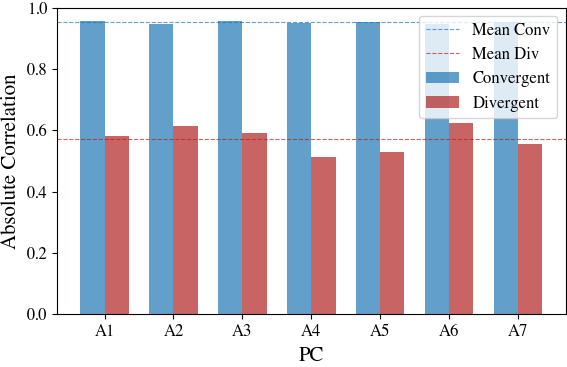

In [235]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlations for PC1, PC2, PC3
pcs = [f'PC{i+1}' for i in range(7)]
conv_corrs = [conv_score_1, conv_score_2, conv_score_3, conv_score_4, conv_score_5, conv_score_6, conv_score_7]
div_corrs = [div_score_1, div_score_2, div_score_3, div_score_4, div_score_5, div_score_6, div_score_7]

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)

# Add horizontal dashed lines
ax.axhline(y=abs(sum(conv_corrs) / len(conv_corrs)), color='C0', linestyle='--', alpha=0.7, label='Mean Conv', linewidth=0.8)
ax.axhline(y=abs(sum(div_corrs) / len(div_corrs)), color='firebrick', linestyle='--', alpha=0.7, label='Mean Div', linewidth=0.8)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('PC')
ax.set_xticks(x)
ax.set_xticklabels([f'A{i+1}' for i in range(7)])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(f'../result/ability_correlations_histogram_{"".join(conv_dataset)}.pdf')
plt.show()

In [236]:
# Get mean scores and find common indices (models that have non-NaN values for both)
common_indices = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].dropna().index.to_list()
print(len(common_indices))
display(common_indices)
# count each company in common_indices
company_counts = {}
for model in common_indices:
    company = model.split('/')[0]
    if company not in company_counts:
        company_counts[company] = 0
    company_counts[company] += 1
print(company_counts)

90


['allenai/olmo-7b',
 'cohere/command-light',
 'AlephAlpha/luminous-base',
 'cohere/command',
 'mistralai/mistral-7b-instruct-v0.3',
 'ai21/j2-jumbo',
 'meta/llama-2-13b',
 'microsoft/phi-2',
 'meta/llama-3.2-11b-vision-instruct-turbo',
 'meta/llama-3.1-8b-instruct-turbo',
 'cohere/command-r',
 'mistralai/mistral-medium-2312',
 'AlephAlpha/luminous-supreme',
 'mistralai/mistral-7b-v0.1',
 'google/gemini-1.0-pro-002',
 'AlephAlpha/luminous-extended',
 'cohere/command-r-plus',
 'databricks/dbrx-instruct',
 '01-ai/yi-6b',
 'openai/gpt-3.5-turbo-0613',
 'tiiuae/falcon-40b',
 'meta/llama-65b',
 'qwen/qwen1.5-7b',
 'meta/llama-2-7b',
 'meta/llama-2-70b',
 'anthropic/claude-2.0',
 'mistralai/open-mistral-nemo-2407',
 'tiiuae/falcon-7b',
 'ai21/jamba-instruct',
 'google/gemma-7b',
 'meta/llama-3-8b',
 'openai/text-davinci-002',
 'openai/text-davinci-003',
 'ai21/jamba-1.5-mini',
 'mistralai/mistral-small-2402',
 'ai21/j2-grande',
 'snowflake/snowflake-arctic-instruct',
 'mistralai/mistral-large

{'allenai': 1, 'cohere': 4, 'AlephAlpha': 3, 'mistralai': 9, 'ai21': 5, 'meta': 12, 'microsoft': 2, 'google': 11, 'databricks': 1, '01-ai': 3, 'openai': 9, 'tiiuae': 2, 'qwen': 8, 'anthropic': 10, 'snowflake': 1, 'writer': 3, 'deepseek-ai': 2, 'amazon': 3, 'upstage': 1}


meta/llama-3.1-405b-instruct-turbo          2.848733
meta/llama-3.2-90b-vision-instruct-turbo    2.555545
meta/llama-3.3-70b-instruct-turbo           2.350719
meta/llama-3.1-70b-instruct-turbo           2.340164
meta/llama-3-70b                            1.309260
meta/llama-3.1-8b-instruct-turbo            1.202192
meta/llama-3.2-11b-vision-instruct-turbo    1.101618
meta/llama-2-70b                           -0.492956
meta/llama-3-8b                            -0.714963
meta/llama-65b                             -1.308996
meta/llama-2-13b                           -1.439115
meta/llama-2-7b                            -2.769235
dtype: float64
openai/gpt-4o-2024-08-06         2.519861
openai/gpt-4o-2024-05-13         2.348227
openai/gpt-4-turbo-2024-04-09    1.891671
openai/gpt-4-0613                1.673481
openai/gpt-4-1106-preview        1.327920
openai/gpt-4o-mini-2024-07-18    1.227834
openai/gpt-3.5-turbo-0613        0.236809
openai/text-davinci-003         -0.636895
openai/text-d

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_45962/4260108896.py:177: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


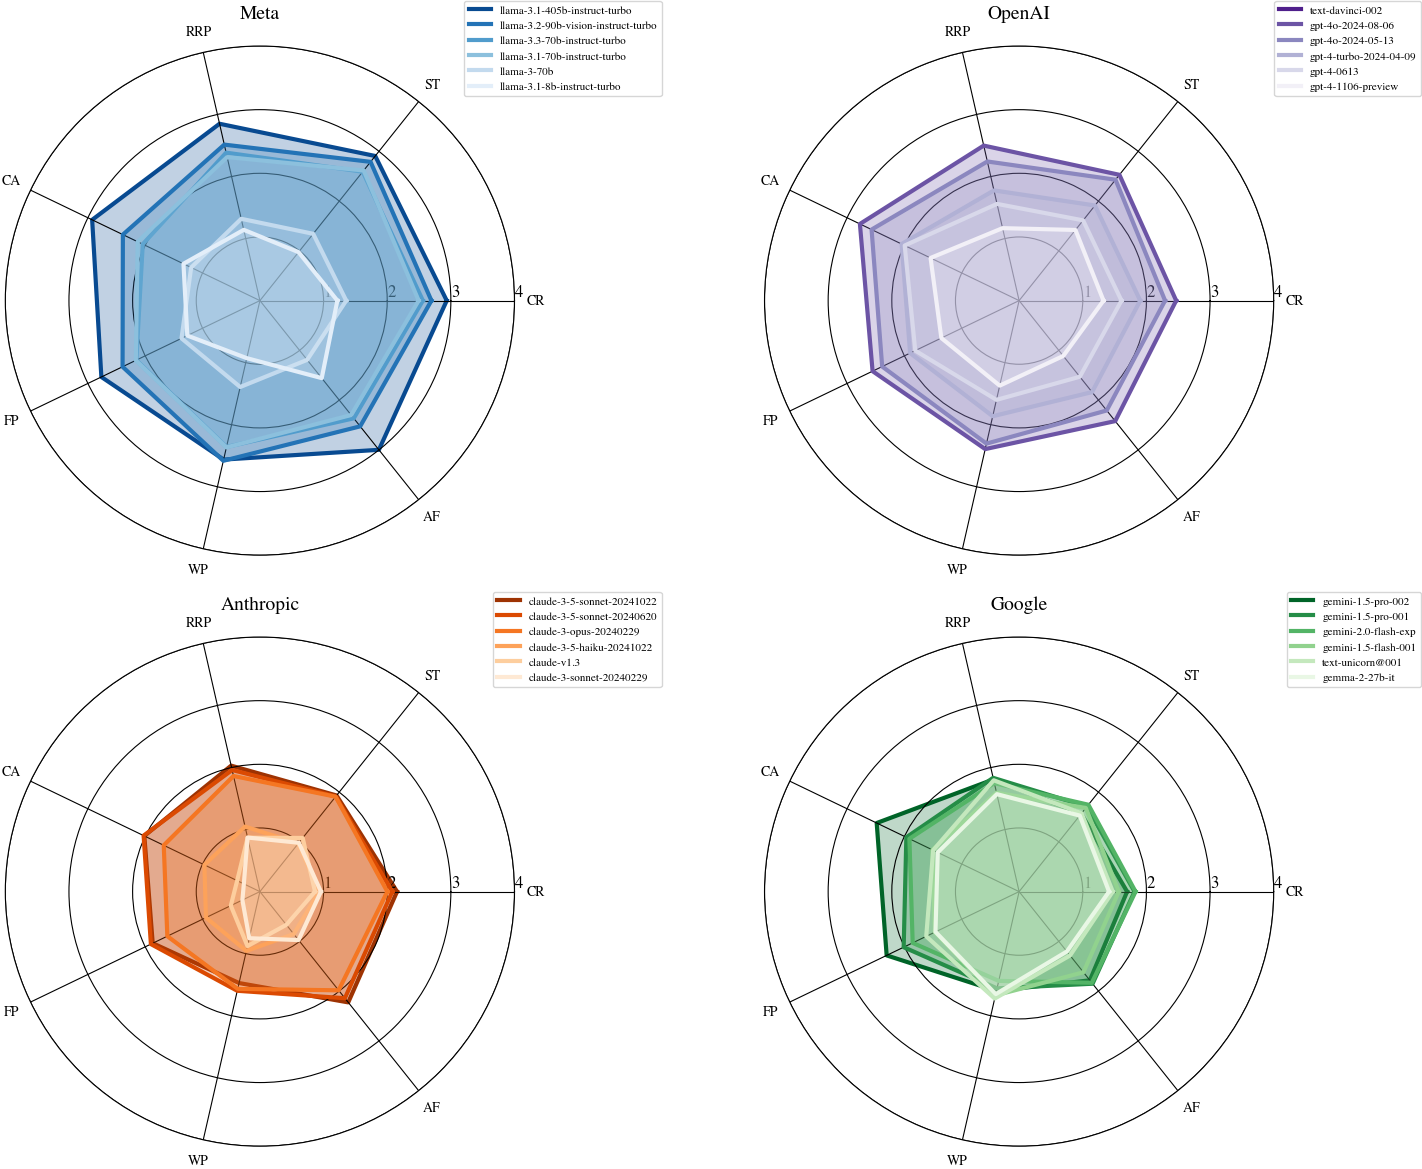

Selected models for radar charts:

META:
  meta/llama-3.1-405b-instruct-turbo
  meta/llama-3.2-90b-vision-instruct-turbo
  meta/llama-3.3-70b-instruct-turbo
  meta/llama-3.1-70b-instruct-turbo
  meta/llama-3-70b
  meta/llama-3.1-8b-instruct-turbo

OPENAI:
  openai/text-davinci-002
  openai/gpt-4o-2024-08-06
  openai/gpt-4o-2024-05-13
  openai/gpt-4-turbo-2024-04-09
  openai/gpt-4-0613
  openai/gpt-4-1106-preview

ANTHROPIC:
  anthropic/claude-3-5-sonnet-20241022
  anthropic/claude-3-5-sonnet-20240620
  anthropic/claude-3-opus-20240229
  anthropic/claude-3-5-haiku-20241022
  anthropic/claude-v1.3
  anthropic/claude-3-sonnet-20240229

GOOGLE:
  google/gemini-1.5-pro-002
  google/gemini-1.5-pro-001
  google/gemini-2.0-flash-exp
  google/gemini-1.5-flash-001
  google/text-unicorn@001
  google/gemma-2-27b-it


In [261]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi

common_indices = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].dropna().index.to_list()

scores_mapping = {
    'CR': score_1,
    'ST': score_2,
    'RRP': score_3,
    'CA': score_4,
    'FP': score_5,
    'WP': score_6,
    'AF': score_7,
}

skill_scores = pd.DataFrame(scores_mapping)

skill_scores = skill_scores.loc[common_indices]

# Function to create radar chart
def create_radar_chart(data, labels, title, ax, colors=None, model_names=None):
    """
    Create a radar chart for given data
    """
    # Number of variables
    N = len(labels)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    # Initialize colors if not provided
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(data)))
    
    # Plot each model
    for i, (model_data, color) in enumerate(zip(data, colors)):
        values = model_data.tolist()
        values += values[:1]  # Complete the circle
        
        model_name = model_names[i] if model_names else f'Model {i+1}'
        # Extract just the model name after the company prefix
        display_name = model_name.split('/')[-1] if '/' in model_name else model_name
        
        ax.plot(angles, values, '-', linewidth=3, label=display_name, color=color, alpha=1, zorder=i + 1)
        ax.fill(angles, values, color=color, alpha=0.25, zorder=i + 1)
    
    # Add labels
    ax.tick_params(pad=5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10, weight='bold')
    ax.set_ylim(0, 4)  # Set consistent scale
    ax.set_title(title, size=14, weight='bold', pad=20)
    ax.grid(True, alpha=1, color='black', zorder=10)
    
    # Ensure y-ticks align with circles
    ax.set_rgrids([1, 2, 3, 4], angle=0, labels=["1", "2", "3", "4"], fontsize=12)

    # Hide the zero label
    ax.set_rmin(0)

# Filter and group models by company
companies = {
    'meta': [],
    'openai': [], 
    'anthropic': [],
    'google': []
}

# Group models by company prefix (only include models that have all 4 skill scores)
common_models = skill_scores.dropna().index
for model in common_models:
    if model.startswith('meta/'):
        companies['meta'].append(model)
    elif model.startswith('openai/'):
        companies['openai'].append(model)
    elif model.startswith('anthropic/'):
        companies['anthropic'].append(model)
    elif model.startswith(('google/')):
        companies['google'].append(model)

# UPDATED VERSION: Select top models from each company with explicit model inclusion
def select_top_models(models, n=6, explicit_models=None):
    """
    Select top models from a list, with option to include explicit models.
    
    Args:
        models: List of model names to choose from
        n: Number of top models to select
        explicit_models: List of model names that must be included if they exist in models
        
    Returns:
        List of selected model names
    """
    if not models:
        return []
    
    # Initialize result with explicit models that exist in the models list
    result = []
    if explicit_models:
        result = [model for model in explicit_models if model in models]
    
    # If we already have enough models from explicit list, return them
    if len(result) >= n:
        return result[:n]
    
    # Get model scores and sort by performance
    model_scores = skill_scores.loc[models].mean(axis=1).sort_values(ascending=False)
    print(model_scores)
    
    # Add top performing models that aren't already in the result
    remaining_slots = n - len(result)
    for model in model_scores.index:
        if model not in result:
            result.append(model)
            remaining_slots -= 1
            if remaining_slots == 0:
                break
    
    return result

# Define explicit models to include for each company
explicit_models_by_company = {
    'openai': ['openai/text-davinci-002'],
    # Add other companies and their explicit models as needed
    # 'anthropic': ['anthropic/claude-v1'],
    # 'google': ['google/specific-model'],
    # etc.
}

# Get top models for each company with explicit model inclusion
selected_models = {
    company: select_top_models(
        models, 
        n=6, 
        explicit_models=explicit_models_by_company.get(company, [])
    ) 
    for company, models in companies.items()
}
# Create the radar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

# Skill labels 
skill_labels = scores_mapping.keys()

company_names = ['Meta', 'OpenAI', 'Anthropic', 'Google']
company_keys = ['meta', 'openai', 'anthropic', 'google']

for i, (company_key, company_name) in enumerate(zip(company_keys, company_names)):
    models = selected_models[company_key]
    if models:
        # Get data for selected models using skill scores
        model_data = skill_scores.loc[models].values
        
        # Create color palette for this company
        if company_key == 'meta':
            colors = plt.cm.Blues_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'openai':
            colors = plt.cm.Purples_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'anthropic':
            colors = plt.cm.Oranges_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'google':
            colors = plt.cm.Greens_r(np.linspace(0.1, 0.9, len(models)))
        create_radar_chart(model_data, skill_labels, company_name, axes[i], 
                         colors=colors, model_names=models)
        
        # Add legend with abbreviated names
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    else:
        axes[i].text(0.5, 0.5, f'No {company_name} models found', 
                    transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('../result/model_families_math_skill_radar_charts.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print summary of selected models and their scores
print("Selected models for radar charts:")
for company, models in selected_models.items():
    print(f"\n{company.upper()}:")
    for model in models:
        scores = skill_scores.loc[model]
        print(f"  {model}")